Zadanie 9

Srednia empiryczna: 10.069
Srednia teoretyczna: 10.0


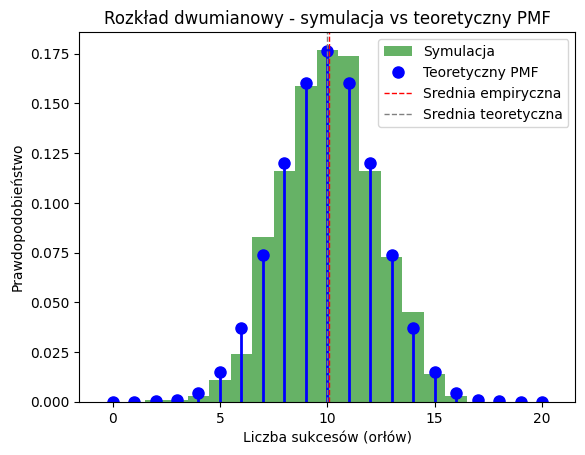

In [12]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

n = 20 
p = 0.5 
num_experiments = 1000 
data = np.random.binomial(n, p, num_experiments)


plt.hist(data, bins=np.arange(-0.5, n+1.5), density=True  , alpha=0.6, color='g', label='Symulacja')

x = np.arange(0, n+1)
pmf = binom.pmf(x, n, p)
plt.plot(x, pmf, 'bo', ms=8, label='Teoretyczny PMF')
plt.vlines(x, 0, pmf, colors='b', lw=2)
empirical_mean = np.mean(data)
theoretical_mean = n * p
print(f'Srednia empiryczna: {empirical_mean}')
print(f'Srednia teoretyczna: {theoretical_mean}')
plt.axvline(empirical_mean, color='r', linestyle='dashed', linewidth=1, label='Srednia empiryczna')
plt.axvline(theoretical_mean, color='gray', linestyle='dashed', linewidth=1, label='Srednia teoretyczna')  
plt.title('Rozkład dwumianowy - symulacja vs teoretyczny PMF')
plt.xlabel('Liczba sukcesów (orłów)')
plt.ylabel('Prawdopodobieństwo')
plt.legend()
plt.show()
#

Zadanie 10

Liczba outlierów: 8


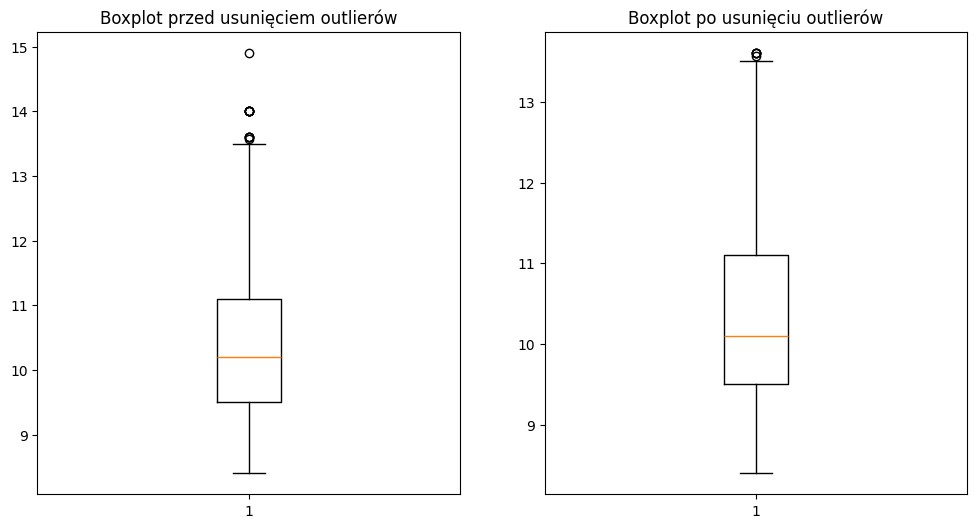

Statystyki przed usunięciem outlierów:
Mean: 10.42, Median: 10.2, Std: 1.07
Statystyki po usunięciu outlierów:
Mean: 10.4, Median: 10.1, Std: 1.04


In [11]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine = pd.read_csv(url, sep=';')

mean_alcohol = wine['alcohol'].mean()
std_alcohol = wine['alcohol'].std()
wine['z_score'] = (wine['alcohol'] - mean_alcohol) / std_alcohol

outliers = wine[np.abs(wine['z_score']) > 3]
print(f'Liczba outlierów: {len(outliers)}')

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.boxplot(wine['alcohol'])
plt.title('Boxplot przed usunięciem outlierów')
#
wine_cleaned = wine[np.abs(wine['z_score']) <= 3]

plt.subplot(1, 2, 2)
plt.boxplot(wine_cleaned['alcohol'])
plt.title('Boxplot po usunięciu outlierów')
plt.show() 

mean_before = round(wine['alcohol'].mean(),2)
median_before = round(wine['alcohol'].median(),2)
std_before = round(wine['alcohol'].std(),2)
mean_after = round(wine_cleaned['alcohol'].mean(),2)
median_after = round(wine_cleaned['alcohol'].median(),2)
std_after = round(wine_cleaned['alcohol'].std(),2)  
print(f'Statystyki przed usunięciem outlierów:')
print(f'Mean: {mean_before}, Median: {median_before}, Std: {std_before}')
print(f'Statystyki po usunięciu outlierów:')
print(f'Mean: {mean_after}, Median: {median_after}, Std: {std_after}')  